In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [3]:
df.head()

,order_date,ship_date,ship_mode,segment,country,city,state,postal_code,region,category,sub-category,sales,quantity,discount,profit
0,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,2016-06-16,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.shape


(9994, 15)

### 1. Histplot of Profit(Full range)

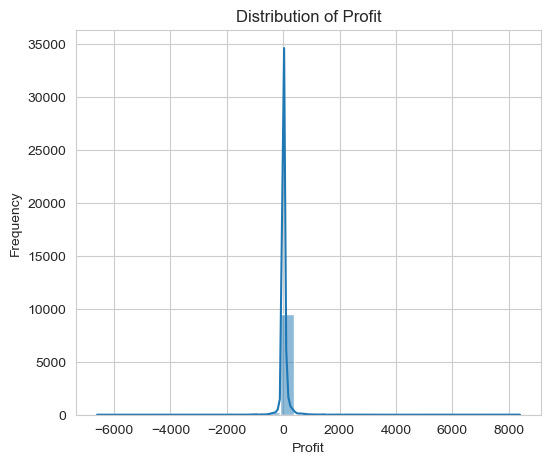

In [16]:
plt.figure(figsize=(6, 5))
sns.histplot(df["profit"], bins=30, kde=True)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

Observation - Most orders generate profits close to zero, while a small number of orders have very high profits or significant losses, resulting in a highly right-skewed distribution with noticeable outliers.

### Histplot of Profit(Zoomed: -500 to 500)

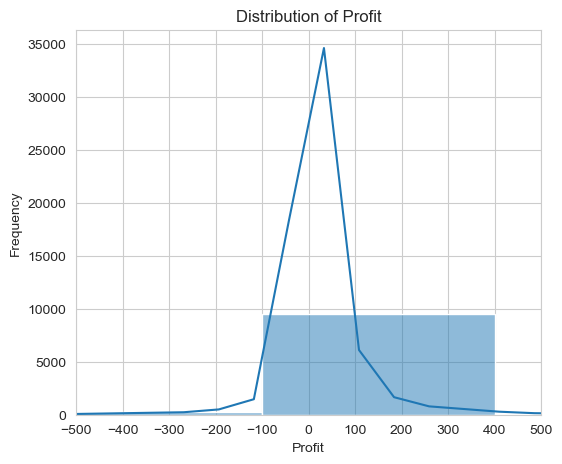

In [29]:

plt.figure(figsize=(6,5))

sns.histplot(df["profit"], bins=30, kde=True)

plt.xlim(-500, 500)                    # Zoom into the central region
plt.xticks(np.arange(-500, 501, 100))  # Tick every 100

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

Observation - A- After zooming into the central range, it is evident that the majority of orders have profits between -100 and 100, with the highest concentration around small positive profits.

B- This indicates that most transactions yield relatively modest profits, while extreme profit and loss values are rare.

### 2. Boxplot of Profit by Category

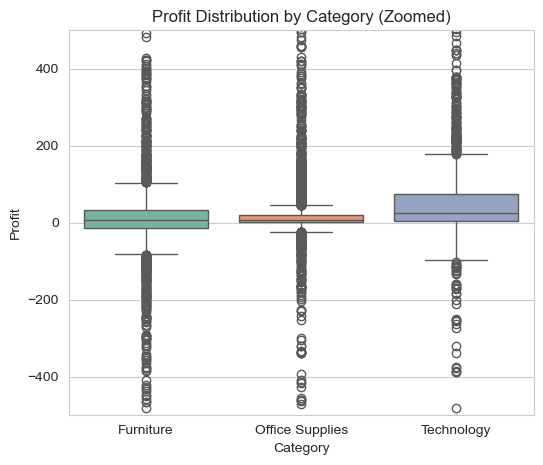

In [28]:

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df,
    x="category",
    y="profit",
    hue="category",
    palette="Set2"
)

plt.ylim(-500, 500)   # Zoom into the central profit range

plt.title("Profit Distribution by Category (Zoomed)")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

Observation: A- Technology has the highest median profit and the widest spread of profits, indicating that technology products generally generate higher profits but also show greater variability.

B- Furniture and Office Supplies have lower median profits, with Furniture exhibiting more frequent loss-making orders.

### 3. Scatterplot of Discount vs Profit

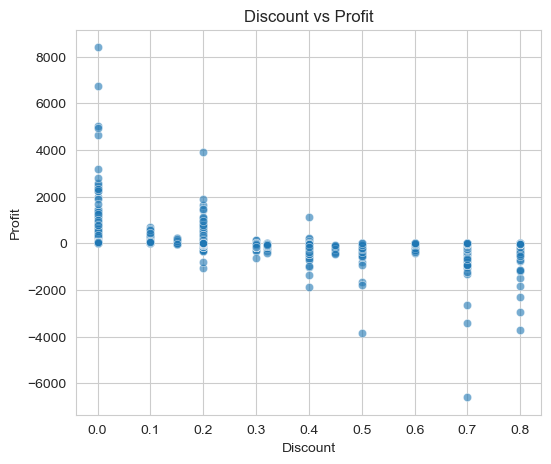

In [33]:

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Observation A- As the discount increases, the profit generally decreases, with higher discount levels (0.5–0.8) showing a greater number of loss-making orders.

B- Orders with little or no discount (0.0–0.2) exhibit the widest range of profits, including the highest positive profits, indicating that lower discounts are more likely to generate profitable sales.

### Discount vs Profit by category

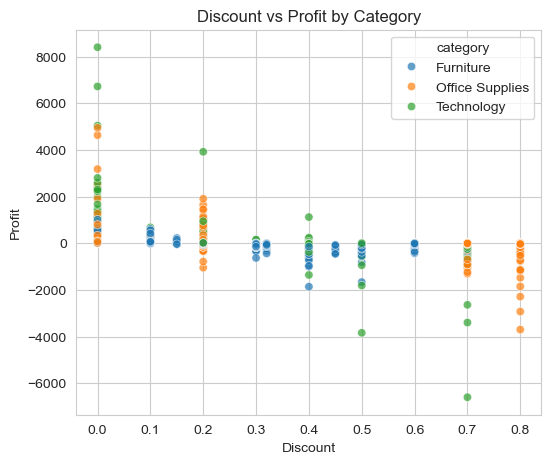

In [34]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    hue="category",
    alpha=0.7
)

plt.title("Discount vs Profit by Category")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()


Observation A- Technology products achieve the highest profits at low discount levels, while high discounts substantially reduce profitability across all categories.

B- Furniture and Office Supplies experience more negative profits at higher discount levels (0.7–0.8), suggesting that excessive discounting has a stronger adverse impact on these categories.

### 4. Countplot of Region

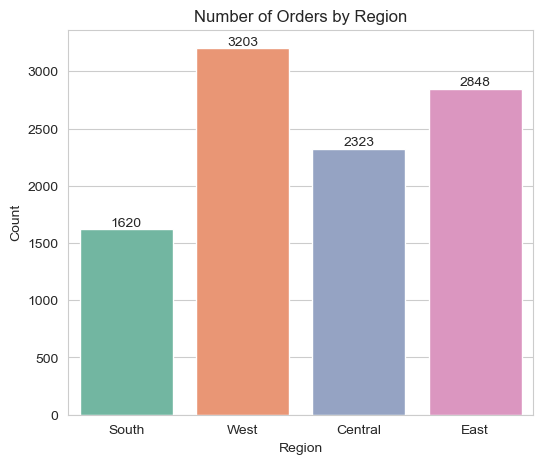

In [36]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="region",
    palette="Set2",
    hue="region",
    legend=False
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Orders by Region")
plt.xlabel("Region")
plt.ylabel("Count")

plt.show()

Observation A- The West region has the highest number of orders (3,203), followed by the East region (2,848), indicating that these regions contribute the largest share of total sales transactions.

B- The South region has the fewest orders (1,620), suggesting lower customer activity or market presence compared to the other regions.

### 5. Correlation heatmap of Sales, Quantity, Discount, Profit

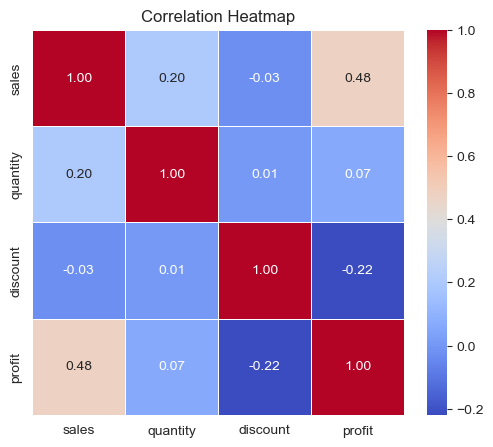

In [37]:
corr = df[["sales", "quantity", "discount", "profit"]].corr()

# Create heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,        # Display correlation values
    cmap="coolwarm",   # Color palette
    fmt=".2f",         # Show values up to 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Observation A- Sales has the strongest positive correlation with Profit (0.48), indicating that orders with higher sales tend to generate higher profits, although the relationship is only moderate.

B- Discount has a negative correlation with Profit (-0.22), suggesting that increasing discounts generally reduce profitability. In contrast, Quantity shows a very weak correlation with Profit (0.07), indicating it has little direct linear relationship with profit.

### 6. Regplot of Discount vs Profit

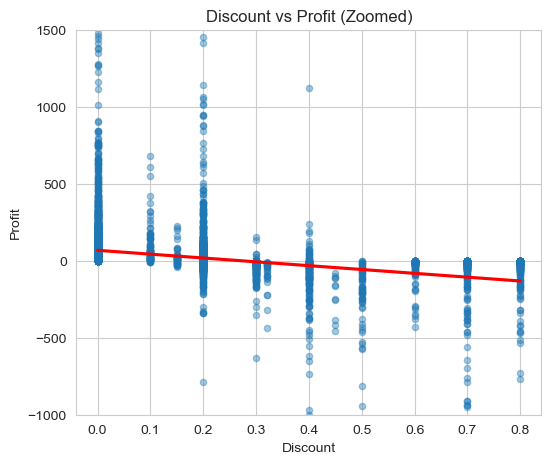

In [41]:
plt.figure(figsize=(6,5))

sns.regplot(
    data=df,
    x="discount",
    y="profit",
    scatter_kws={"alpha": 0.4, "s": 20},
    line_kws={"color": "red"},
    ci=None
)

plt.ylim(-1000, 1500)

plt.title("Discount vs Profit (Zoomed)")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Observation A- The regression line has a negative slope, indicating that profit tends to decrease as the discount increases. This suggests that offering higher discounts generally reduces order profitability.

B- Orders with low or no discount (0.0–0.2) exhibit the highest positive profits, whereas higher discounts (0.5–0.8) are predominantly associated with low or negative profits, indicating that excessive discounting often leads to loss-making orders.

### 7. Faceted boxplot of Profit by Category, col=Region

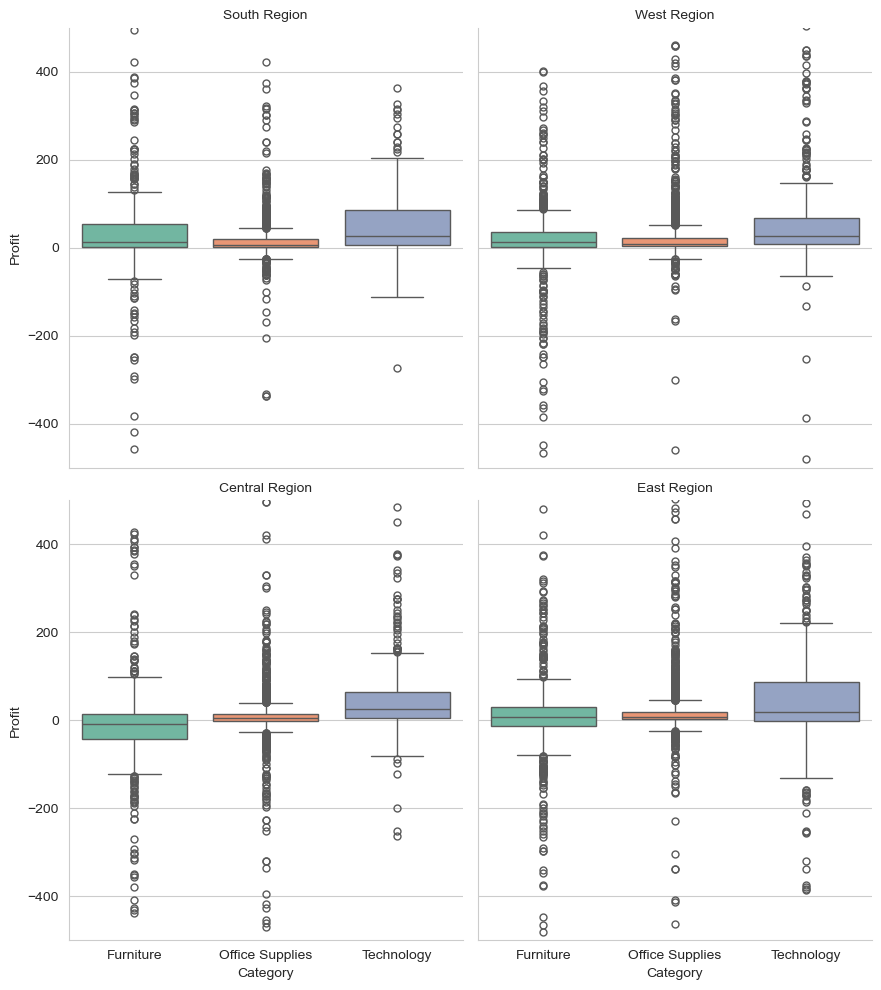

In [46]:
g = sns.catplot(
    data=df,
    x="category",
    y="profit",
    col="region",
    col_wrap=2,
    kind="box",
    palette="Set2",
    hue="category",
    legend=False,
    height=5,
    aspect=0.9
)

g.set(ylim=(-500, 500))

g.set_titles("{col_name} Region")
g.set_axis_labels("Category", "Profit")

plt.show()

Observations A- The Technology category has the highest median profit in every region, with most orders being profitable despite some variability.

B- Furniture has a lower median profit and a larger spread into negative profits across regions, indicating frequent unprofitable transactions.